In [1]:
import kagglehub 
import numpy as np
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from kagglehub import KaggleDatasetAdapter 



In [31]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)  



In [3]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

In [4]:
df["time"].describe()

count    299.000000
mean     130.260870
std       77.614208
min        4.000000
25%       73.000000
50%      115.000000
75%      203.000000
max      285.000000
Name: time, dtype: float64

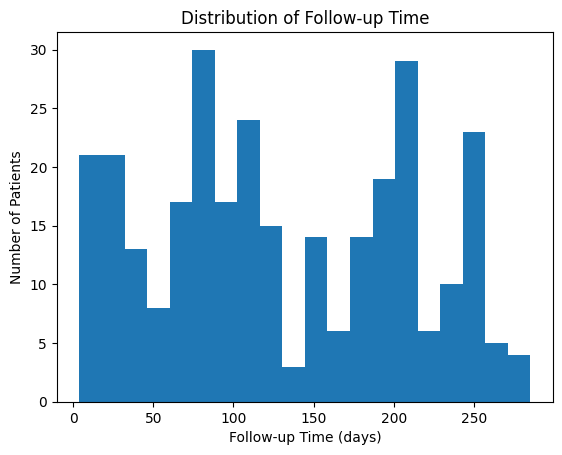

In [5]:
plt.hist(df["time"], bins=20)
plt.xlabel("Follow-up Time (days)")
plt.ylabel("Number of Patients")
plt.title("Distribution of Follow-up Time")
plt.show()

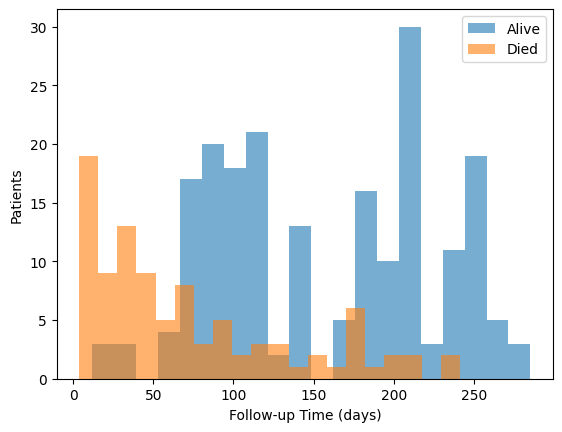

In [6]:
alive = df[df["DEATH_EVENT"] == 0]["time"]
dead = df[df["DEATH_EVENT"] == 1]["time"]

plt.hist(alive, bins=20, alpha=0.6, label="Alive")
plt.hist(dead, bins=20, alpha=0.6, label="Died")
plt.xlabel("Follow-up Time (days)")
plt.ylabel("Patients")
plt.legend()
plt.show()

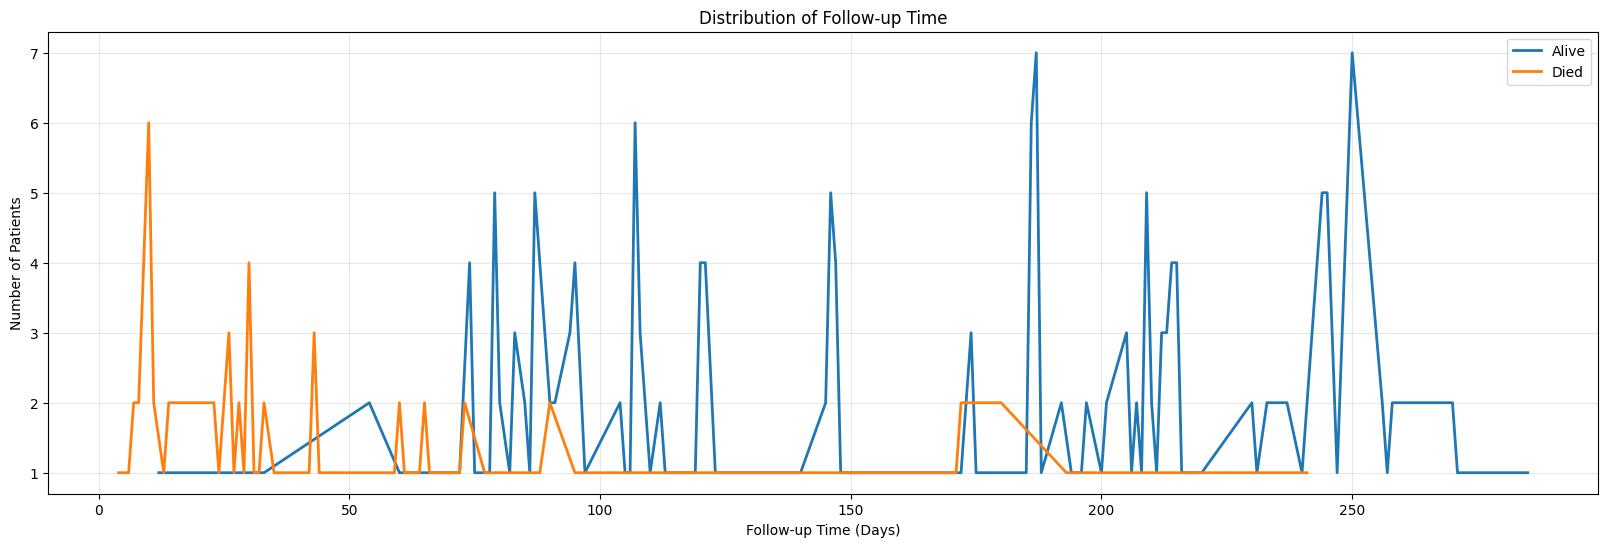

In [7]:
# Split into two groups
alive = df[df["DEATH_EVENT"] == 0]
dead = df[df["DEATH_EVENT"] == 1]

# Count patients by follow-up day
alive_counts = alive["time"].value_counts().sort_index()
dead_counts = dead["time"].value_counts().sort_index()

# Plot
plt.figure(figsize=(20,6))

plt.plot(alive_counts.index,
         alive_counts.values,
         label="Alive",
         linewidth=2)

plt.plot(dead_counts.index,
         dead_counts.values,
         label="Died",
         linewidth=2)

plt.xlabel("Follow-up Time (Days)")
plt.ylabel("Number of Patients")
plt.title("Distribution of Follow-up Time")
plt.legend()

plt.grid(alpha=0.3)
plt.show()

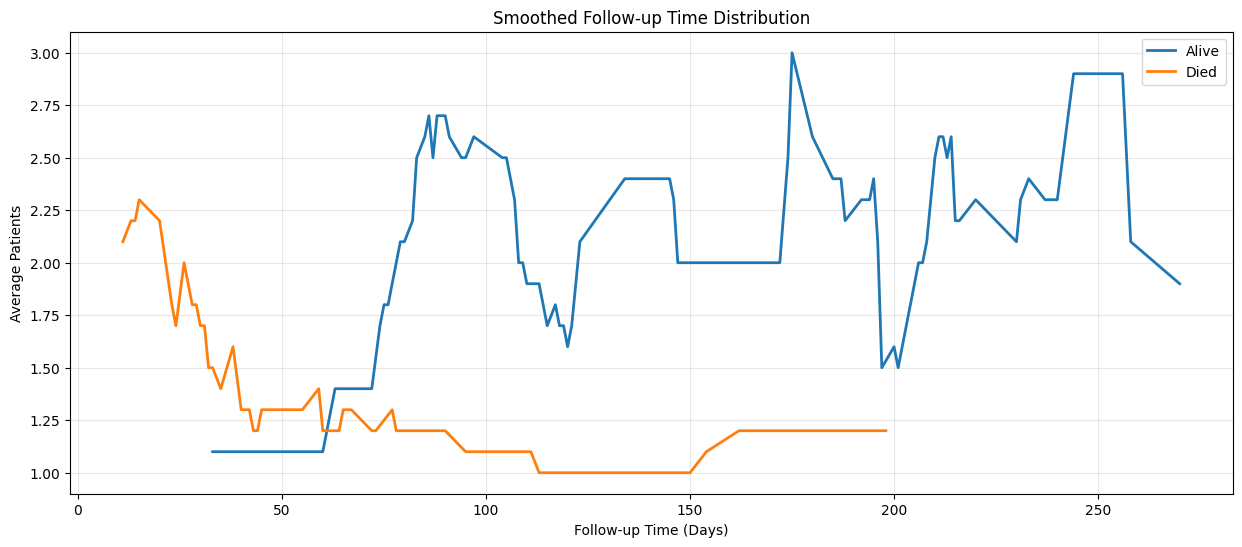

In [8]:
alive_smooth = alive_counts.rolling(window=10, center=True).mean()
dead_smooth = dead_counts.rolling(window=10, center=True).mean()

plt.figure(figsize=(15,6))

plt.plot(alive_smooth.index,
         alive_smooth.values,
         label="Alive",
         linewidth=2)

plt.plot(dead_smooth.index,
         dead_smooth.values,
         label="Died",
         linewidth=2)

plt.xlabel("Follow-up Time (Days)")
plt.ylabel("Average Patients")
plt.title("Smoothed Follow-up Time Distribution")
plt.legend()

plt.grid(alpha=0.3)
plt.show()

In [9]:
bins = [40, 50, 60, 70, 80, 90, 100]

labels = [
    "40-49",
    "50-59",
    "60-69",
    "70-79",
    "80-89",
    "90-99"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=False
)

In [ ]:
columns = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "smoking"
]

summary = (
    df.groupby("age_group")[columns]
      .sum()


)

summary = summary.rename(columns={'high_blood_pressure': 'high blood pressure'})

summary

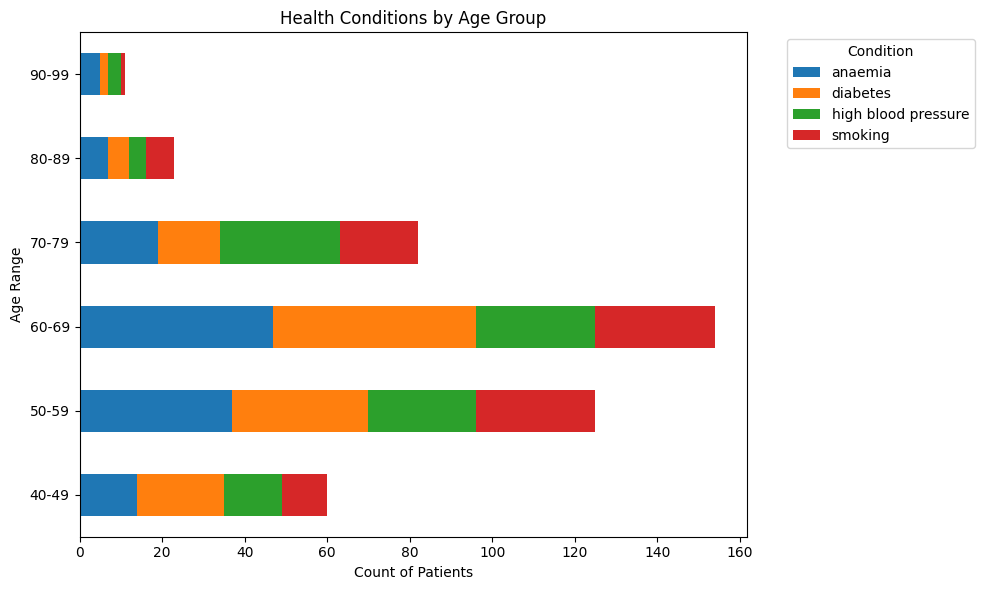

In [11]:
summary.plot(
    kind="barh",
    stacked=True,
    figsize=(10,6)
)

plt.xlabel("Count of Patients")
plt.ylabel("Age Range")
plt.title("Health Conditions by Age Group")

plt.legend(
    title="Condition",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

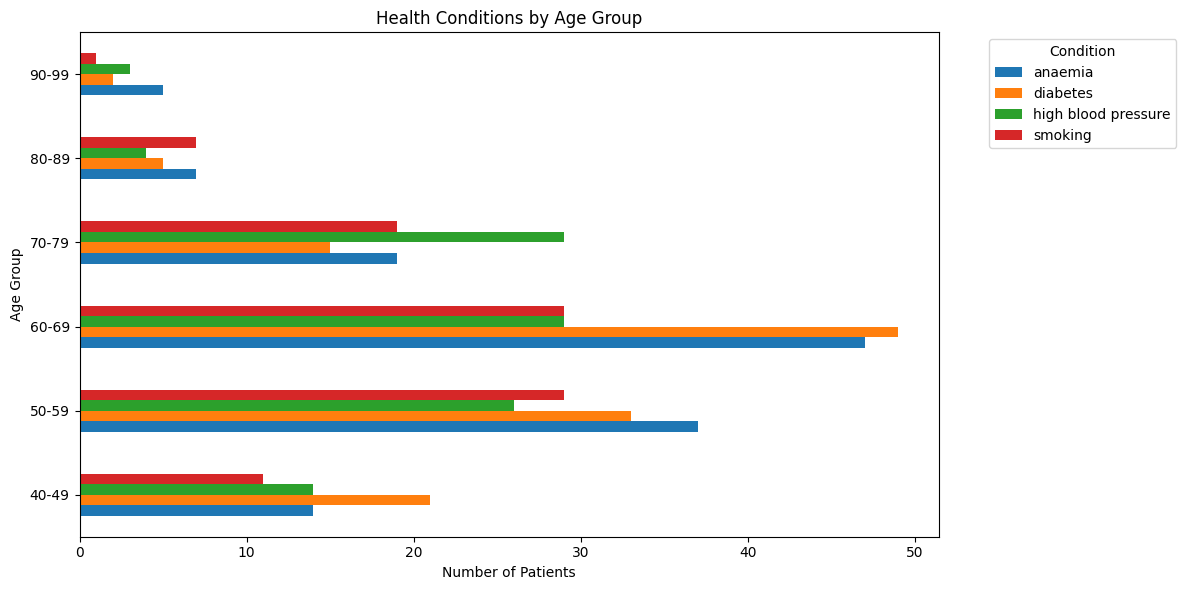

In [12]:
summary.plot(
    kind="barh",
    figsize=(12,6)
)

plt.xlabel("Number of Patients")
plt.ylabel("Age Group")
plt.title("Health Conditions by Age Group")

plt.legend(
    title="Condition",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
columns_counts = df.groupby("age_group")[columns].sum()

age_group_counts = df.groupby("age_group").size()

condition_percent = (
    columns_counts
    .div(age_group_counts, axis=0)
    * 100
)

condition_percent = condition_percent.rename(columns={'high_blood_pressure': 'high blood pressure'})


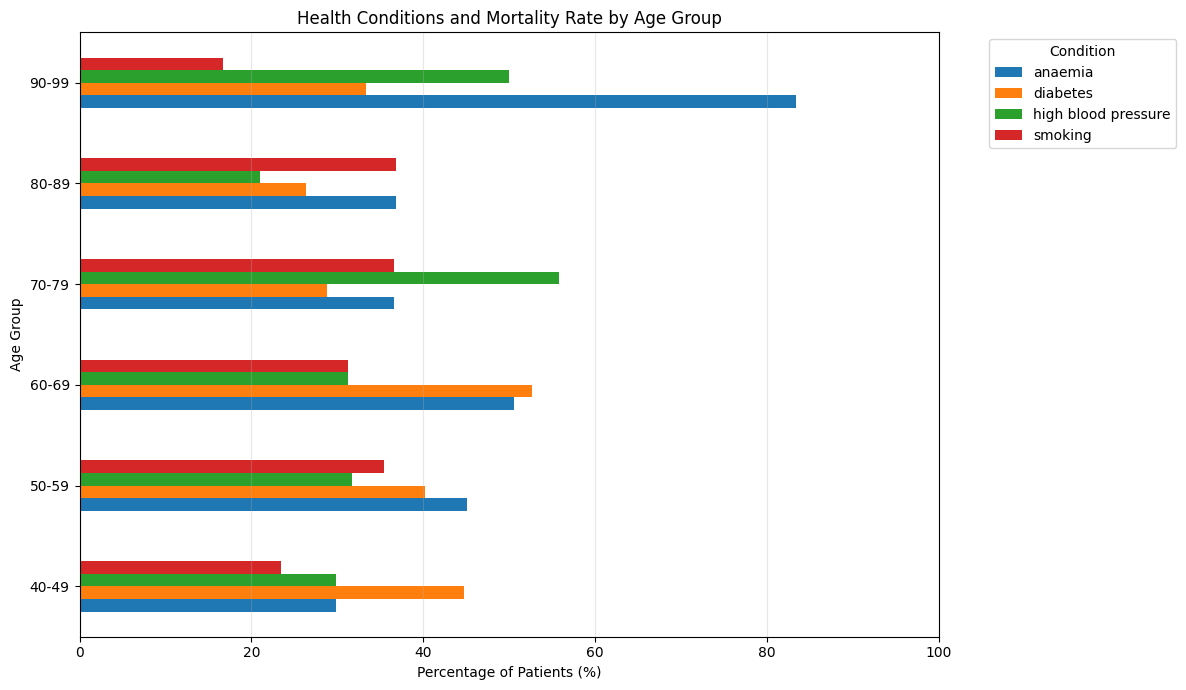

In [14]:
condition_percent.plot(
    kind="barh",
    figsize=(12,7)
)

plt.xlabel("Percentage of Patients (%)")
plt.ylabel("Age Group")
plt.title("Health Conditions and Mortality Rate by Age Group")

plt.legend(
    title="Condition",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.xlim(0,100)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

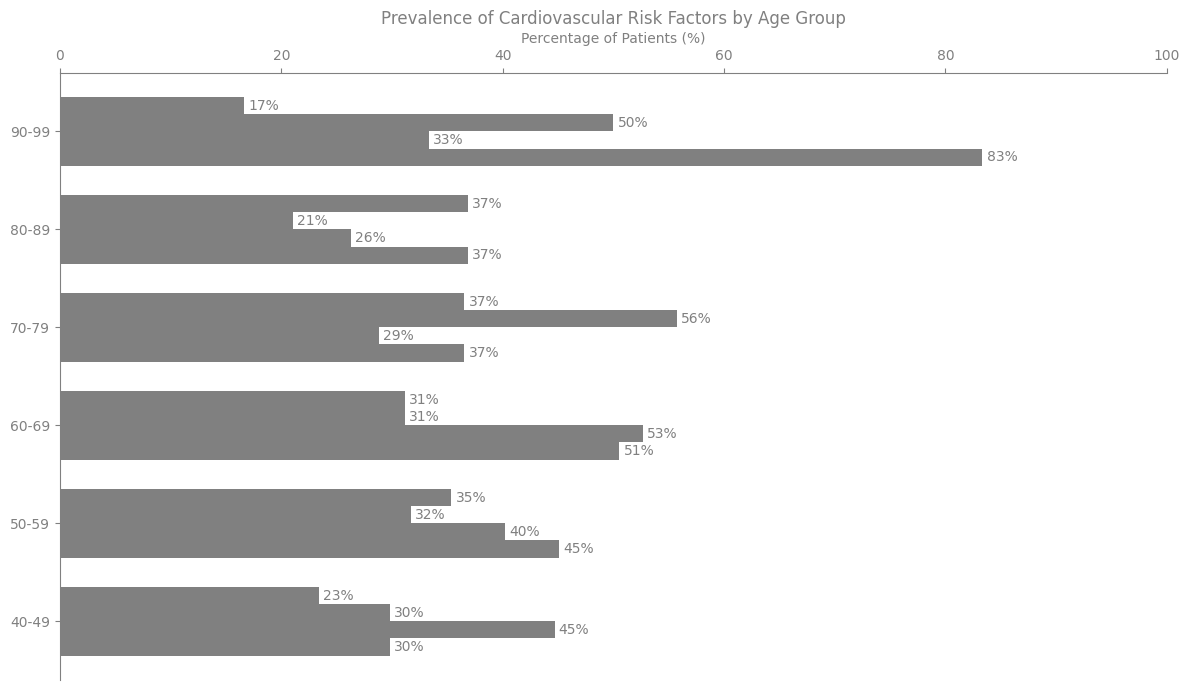

In [15]:
ax = condition_percent.plot(
    kind="barh",
    figsize=(12,7),
    width=0.70,
    color="gray"
)

plt.title(
    "Prevalence of Cardiovascular Risk Factors by Age Group",
    color="gray"
)

# Move x-axis ticks to the top
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# Remove bottom and right borders
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep top border
ax.spines["top"].set_visible(True)
ax.spines["top"].set_color("gray")

# Make left border gray
ax.spines["left"].set_color("gray")

# Remove gridlines
ax.grid(False)

# Make tick labels gray
ax.tick_params(axis="both", colors="gray")

# Make x-axis label gray
ax.xaxis.label.set_color("gray")

# Remove legend
ax.get_legend().remove()

# Set percentage scale
ax.set_xlim(0,100)

# Increase spacing between grouped bars
ax.margins(y=0.15)

plt.xlabel("Percentage of Patients (%)")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f%%",
        padding=3,
        color="gray"
    )

plt.tight_layout()
plt.show()



In [16]:
plt.rcParams["font.family"] = "Arial"

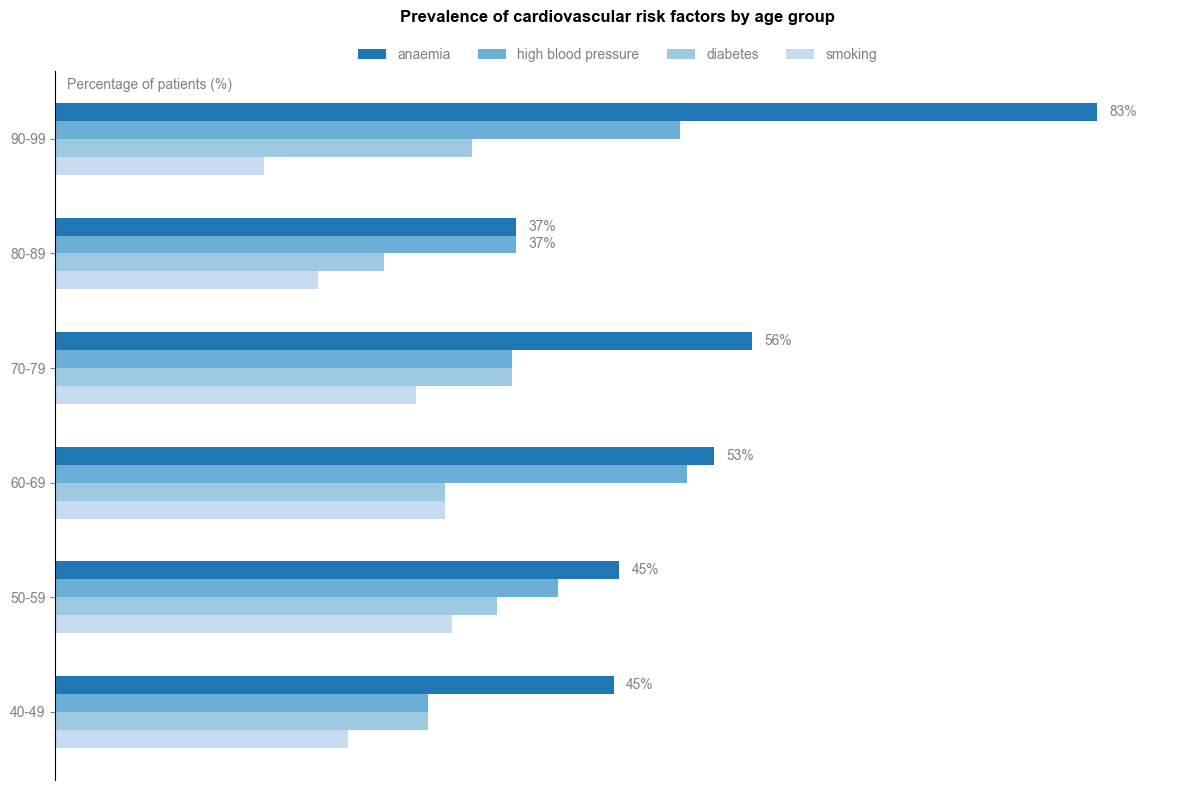

In [17]:
fig, ax = plt.subplots(figsize=(12,8))

bar_height = 0.23
group_spacing = 0.55

y_positions = []
y_labels = []

current_y = 0

# Store legend information
legend_handles = {}

# Define gradient colors (darkest -> lightest -> gray)
colors = [
    "#1f77b4",  # highest percentage
    "#6baed6",
    "#9ecae1",
    "#c6dbef"   # lowest percentage
]

for age_group in condition_percent.index[::-1]:

    # Sort conditions within this age group
    sorted_conditions = (
        condition_percent.loc[age_group]
        .sort_values(ascending=False)
    )

    start_position = current_y

    for i, (condition, percentage) in enumerate(sorted_conditions.items()):

        bar_color = colors[i]

        bar = ax.barh(
            current_y,
            percentage,
            height=bar_height,
            color=bar_color
        )

        # Save one example patch for the legend
        if condition not in legend_handles:
            legend_handles[condition] = bar[0]

        # Percentage labels
        if percentage == sorted_conditions.max():
            ax.text(
            percentage + 1,
            current_y,
            f"{percentage:.0f}%",
            va="center",
            color="gray"
         )

        current_y += bar_height

    # Center age label
    middle = (start_position + current_y - bar_height) / 2

    y_positions.append(middle)
    y_labels.append(age_group)

    current_y += group_spacing


# Age labels
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels)


# Move x-axis to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

ax.tick_params(
    axis="x",
    which="both",
    bottom=False,
    top=False,
    labelbottom=False,
    labeltop=False
)

ax.text(
    0.01,
    .97,
    "Percentage of patients (%)",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color="gray"
)

# Formatting
ax.set_xlim(0,90)

ax.tick_params(axis="both", colors="gray")

ax.spines["top"].set_visible(False)
ax.spines["top"].set_color("gray")

ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)


# Legend below title, left-to-right
legend_order = list(legend_handles.keys())

legend = ax.legend(
    [legend_handles[key] for key in legend_order],
    legend_order,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=len(legend_order),
    frameon=False
)

for text in legend.get_texts():
    text.set_color("gray")

plt.title(
    "Prevalence of cardiovascular risk factors by age group",
    color="black",
    fontweight="bold",
    pad=35
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [18]:
death_by_anaemia = (
    df.groupby("anaemia")["DEATH_EVENT"]
      .mean()
      .mul(100)
)

print(death_by_anaemia)

anaemia
0    29.411765
1    35.658915
Name: DEATH_EVENT, dtype: float64


In [ ]:
anaemia_death_age = (
    df.groupby(["age_group", "anaemia"])["DEATH_EVENT"]
      .mean()
      .mul(100)
      .unstack()
)

print(anaemia_death_age)

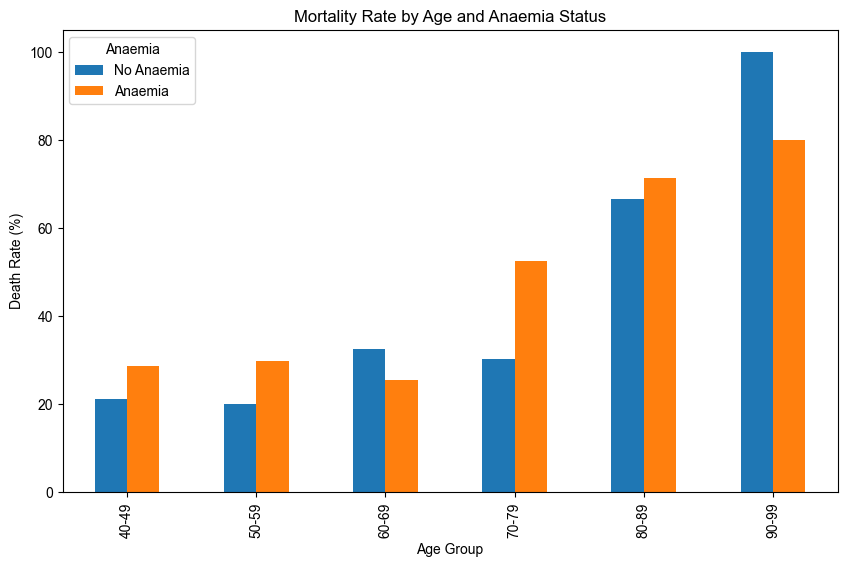

In [20]:
anaemia_death_age.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Death Rate (%)")
plt.xlabel("Age Group")
plt.title("Mortality Rate by Age and Anaemia Status")
plt.legend(
    ["No Anaemia", "Anaemia"],
    title="Anaemia"
)

plt.show()

In [21]:
risk_factors = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "smoking"
]

mortality = {}

for factor in risk_factors:
    mortality[factor] = (
        df.groupby(factor)["DEATH_EVENT"]
          .mean()
          .loc[1] * 100
    )

mortality = pd.Series(mortality)

print(mortality)

anaemia                35.658915
diabetes               32.000000
high_blood_pressure    37.142857
smoking                31.250000
dtype: float64


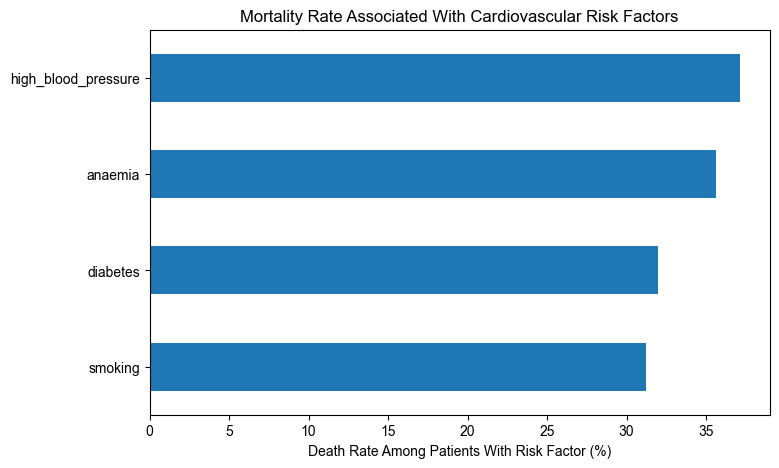

In [22]:
mortality.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.xlabel("Death Rate Among Patients With Risk Factor (%)")
plt.title("Mortality Rate Associated With Cardiovascular Risk Factors")

plt.show()

In [23]:
df.groupby("DEATH_EVENT")["age"].describe() 

,count,mean,std,min,25%,50%,75%,max
DEATH_EVENT,,,,,,,,
0,203.0,58.761906,10.637890,40.0,50.0,60.0,65.0,90.0
1,96.0,65.215281,13.214556,42.0,55.0,65.0,75.0,95.0


In [24]:
correlations = df.corr(numeric_only=True)["anaemia"].sort_values()

print(correlations)

creatinine_phosphokinase   -0.190741
time                       -0.141414
smoking                    -0.107290
sex                        -0.094769
platelets                  -0.043786
diabetes                   -0.012729
ejection_fraction           0.031557
high_blood_pressure         0.038182
serum_sodium                0.041882
serum_creatinine            0.052174
DEATH_EVENT                 0.066270
age                         0.088006
anaemia                     1.000000
Name: anaemia, dtype: float64


In [ ]:
df.groupby(["age_group", "anaemia"]).size()

In [ ]:
(
    df.groupby(["age_group", "anaemia"])["DEATH_EVENT"]
      .agg(["sum", "count", "mean"])
)

In [27]:
group_70s = df[df["age_group"] == "70-79"]

group_70s.groupby("anaemia")[
    [
        "ejection_fraction",
        "serum_creatinine",
        "serum_sodium"
    ]
].mean()

,ejection_fraction,serum_creatinine,serum_sodium
anaemia,,,
0,38.121212,1.356061,136.151515
1,39.263158,1.458421,137.631579


In [28]:
from scipy.stats import fisher_exact

#               Died  Survived
table = pd.DataFrame(
    [[10, 23],
     [10,  9]],
    index=["No Anaemia", "Anaemia"],
    columns=["Died", "Survived"]
)

print(table)

            Died  Survived
No Anaemia    10        23
Anaemia       10         9


In [29]:
from scipy.stats import fisher_exact

odds_ratio, p_value = fisher_exact(table)

print(f"Odds Ratio: {odds_ratio:.3f}")
print(f"P-value: {p_value:.4f}")

Odds Ratio: 0.391
P-value: 0.1440


Citation
Davide Chicco, Giuseppe Jurman: Machine learning can predict survival of patients with heart failure from serum creatinine and ejection fraction alone. BMC Medical Informatics and Decision Making 20, 16 (2020). (link)

License
CC BY 4.0

Splash icon
Icon by Freepik, available on Flaticon.

Splash banner
Wallpaper by jcomp, available on Freepik.

https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data
